# 保存/加载街道网络模型到/从磁盘

Author: [Geoff Boeing](https://geoffboeing.com/)

  - [Documentation](https://osmnx.readthedocs.io/)
  - [Journal article and citation info](https://doi.org/10.1111/gean.70009)
  - [Code repository](https://github.com/gboeing/osmnx)
  - [Examples gallery](https://github.com/gboeing/osmnx-examples)
  
本笔记本演示了如何将网络保存为GeoPackage、GraphML文件和.osm格式的XML文件到磁盘，以及如何从GraphML文件加载OSMnx创建的网络。

In [1]:
#!uv pip install --system --quiet osmnx[all]
from pathlib import Path

import osmnx as ox

ox.__version__

'2.0.6'

In [2]:
# 获取一个街道网络
place = "Piedmont, California, USA"
G = ox.graph.graph_from_place(place, network_type="drive")

## GeoPackages for GIS

In [3]:
# 将图保存为GeoPackage格式
ox.io.save_graph_geopackage(G, filepath="./data/piedmont.gpkg")

## 使用GraphML文件保存网络并保留拓扑细节

In [4]:
# 将图保存/加载为graphml文件：这是保存模型的最佳方式
# 便于后续工作
filepath = "./data/piedmont.graphml"
ox.io.save_graphml(G, filepath)
G = ox.io.load_graphml(filepath)

In [5]:
# 如果想在gephi中使用你的模型，请使用gephi兼容模式
ox.io.save_graphml(G, filepath=filepath, gephi=True)

## 用于在Adobe Illustrator中工作的SVG文件

In [6]:
# 将街道网络保存为SVG文件
fig, ax = ox.plot.plot_graph(G, show=False, save=True, close=True, filepath="./images/piedmont.svg")

## 城市设施：保存兴趣点、建筑轮廓等

In [7]:
Path("data").mkdir(parents=True, exist_ok=True)

In [8]:
# 获取所有"amenities"并通过geopandas保存为geopackage文件
gdf = ox.features.features_from_place(place, tags={"amenity": True})
gdf = gdf.apply(lambda c: c.astype(str) if c.name != "geometry" else c, axis=0)
gdf.to_file("./data/pois.gpkg", driver="GPKG") # type: ignore

In [14]:
import geopandas as gpd

gdf = gpd.read_file("./data/pois.gpkg")
gdf.head()

,element,id,addr:city,addr:housenumber,addr:postcode,addr:street,amenity,ele,gnis:feature_id,name,...,parking,building,leisure,surface,capacity:disabled,shelter_type,building:levels,material,type,geometry
0,node,358819251,Piedmont,760,94611,Magnolia Avenue,school,91,1692732,Millennium Alternate High School,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,POINT (-122.23368 37.82291)
1,node,358819659,nan,nan,nan,nan,school,130,1693020,Corpus Christi School,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,POINT (-122.21441 37.81382)
2,node,358819746,nan,nan,nan,nan,place_of_worship,160,1693078,Zion Lutheran Church,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,POINT (-122.21049 37.81865)
3,node,358819748,nan,nan,nan,nan,school,160,1693079,Zion Lutheran School,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,POINT (-122.21108 37.81862)
4,node,358851430,nan,nan,nan,nan,place_of_worship,18,1961805,Kehilla Community Synagogue,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,POINT (-122.24386 37.82021)


<Axes: >

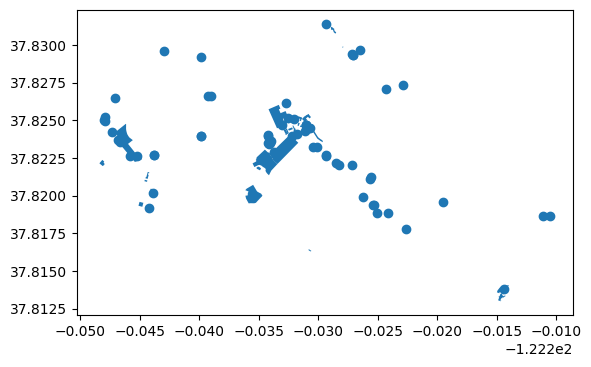

In [15]:
gdf.plot()

In [16]:
# 获取所有建筑轮廓并通过geopandas保存为geopackage文件
gdf = ox.features.features_from_place(place, tags={"building": True})
gdf = gdf.apply(lambda c: c.astype(str) if c.name != "geometry" else c, axis=0)
gdf.to_file("./data/building_footprints.gpkg", driver="GPKG") # type: ignore

In [18]:
gdf = gpd.read_file("./data/building_footprints.gpkg")
gdf.head()

,element,id,addr:city,addr:housenumber,addr:postcode,addr:street,building,name,wikidata,historic,...,layer,tourism,contact:website,denomination,source,fixme,shelter_type,material,type,geometry
0,node,3153686913,Piedmont,7,94611,Croydon Circle,house,nan,nan,nan,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,POINT (-122.21852 37.81518)
1,relation,3349739,Piedmont,120,94611,Vista Avenue,yes,Piedmont City Hall,nan,nan,...,nan,nan,nan,nan,nan,nan,nan,nan,multipolygon,"POLYGON ((-122.23282 37.82437, -122.23271 37.8..."
2,way,28861558,Piedmont,740,94611,Magnolia Avenue,yes,nan,nan,nan,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,"POLYGON ((-122.23486 37.82274, -122.23457 37.8..."
3,way,28861563,nan,nan,nan,nan,yes,nan,nan,nan,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,"POLYGON ((-122.23496 37.82261, -122.23493 37.8..."
4,way,28861579,nan,nan,nan,nan,yes,Morrison Gym,nan,nan,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,"POLYGON ((-122.23401 37.82203, -122.234 37.822..."


## 保存OSM XML文件

要将图形保存为.osm格式的XML文件，请确保在创建图形时设置了`ox.settings.all_oneway=True`，这样`save_graph_xml`才能正常工作。详情请参阅文档字符串。

要保存/加载功能完整的OSMnx图形以便后续使用，请改用`save_graphml`和`load_graphml`函数。

In [19]:
# 将图形保存为.osm格式的XML文件
ox.settings.all_oneway = True
ox.settings.log_console = True
G = ox.graph.graph_from_place("Piedmont, California, USA", network_type="drive", simplify=False)
ox.io.save_graph_xml(G, filepath="./data/piedmont.osm")